# yfinance 펀더멘탈 데이터 수집 가이드

> 우리 프로젝트에서 멀티AI 페이지에 활용할 수 있는 **모든 펀더멘탈 데이터**를 확인합니다.
> 
> - 대상: AAPL (Apple) 예시
> - 목적: PER, ROE, 매출, 성장률, 재무제표 등 시각화 가능한 데이터 전체 확인

In [ ]:
import yfinance as yf
import pandas as pd

# 종목 선택
symbol = "AAPL"
stock = yf.Ticker(symbol)
print(f"=== {symbol} 데이터 로드 완료 ===")

## 1. 기업 개요 (Company Info)

`stock.info` — 가장 핵심. PER, PBR, ROE, 시가총액 등 한 번에 가져올 수 있음.

In [ ]:
info = stock.info

# 가치 평가 지표
valuation = {
    "PER (Trailing)": info.get("trailingPE"),
    "PER (Forward)": info.get("forwardPE"),
    "PBR": info.get("priceToBook"),
    "PSR": info.get("priceToSalesTrailing12Months"),
    "EV/EBITDA": info.get("enterpriseToEbitda"),
    "EV/Revenue": info.get("enterpriseToRevenue"),
    "PEG Ratio": info.get("pegRatio"),
}

# 수익성 지표
profitability = {
    "ROE": info.get("returnOnEquity"),
    "ROA": info.get("returnOnAssets"),
    "영업이익률": info.get("operatingMargins"),
    "순이익률": info.get("profitMargins"),
    "매출총이익률": info.get("grossMargins"),
    "EBITDA 마진": info.get("ebitdaMargins"),
}

# 성장성 지표
growth = {
    "매출 성장률": info.get("revenueGrowth"),
    "이익 성장률": info.get("earningsGrowth"),
    "분기 매출 성장률": info.get("quarterlyRevenueGrowth"),
    "분기 이익 성장률": info.get("quarterlyEarningsGrowth"),
}

# 시장 데이터
market = {
    "시가총액": f"${info.get('marketCap', 0):,.0f}",
    "현재가": info.get("currentPrice"),
    "52주 최고": info.get("fiftyTwoWeekHigh"),
    "52주 최저": info.get("fiftyTwoWeekLow"),
    "50일 이동평균": info.get("fiftyDayAverage"),
    "200일 이동평균": info.get("twoHundredDayAverage"),
    "베타": info.get("beta"),
    "배당수익률": info.get("dividendYield"),
    "배당금": info.get("dividendRate"),
}

# 재무 건전성
financial_health = {
    "부채비율": info.get("debtToEquity"),
    "유동비율": info.get("currentRatio"),
    "속성비율": info.get("quickRatio"),
    "총부채": f"${info.get('totalDebt', 0):,.0f}",
    "총현금": f"${info.get('totalCash', 0):,.0f}",
    "잉여현금흐름": f"${info.get('freeCashflow', 0):,.0f}",
    "영업현금흐름": f"${info.get('operatingCashflow', 0):,.0f}",
}

# 기업 정보
company = {
    "회사명": info.get("longName"),
    "섹터": info.get("sector"),
    "산업": info.get("industry"),
    "직원 수": f"{info.get('fullTimeEmployees', 0):,}명",
    "국가": info.get("country"),
    "웹사이트": info.get("website"),
}

print("=" * 60)
print(f"📊 {symbol} 펀더멘탈 데이터 요약")
print("=" * 60)

for title, data in [
    ("🏢 기업 정보", company),
    ("💰 가치 평가", valuation),
    ("📈 수익성", profitability),
    ("🚀 성장성", growth),
    ("🏦 재무 건전성", financial_health),
    ("📉 시장 데이터", market),
]:
    print(f"\n{title}")
    print("-" * 40)
    for k, v in data.items():
        if isinstance(v, float) and v is not None:
            if abs(v) < 1:  # 비율(%)
                print(f"  {k:20s}: {v:.2%}")
            else:
                print(f"  {k:20s}: {v:.2f}")
        else:
            print(f"  {k:20s}: {v}")

## 2. 손익계산서 (Income Statement)

분기별 매출, 영업이익, 순이익 → **매출/순이익 성장률 그래프** 그릴 수 있음

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# 분기별 손익계산서
quarterly_income = stock.quarterly_income_stmt
print("=== 분기별 손익계산서 (최근 4분기) ===")
print(f"사용 가능한 항목: {list(quarterly_income.index)[:15]}...")

# 핵심 항목 추출
key_items = ['Total Revenue', 'Operating Income', 'Net Income', 'Gross Profit', 'EBITDA']
for item in key_items:
    if item in quarterly_income.index:
        vals = quarterly_income.loc[item]
        print(f"\n{item}:")
        for date, val in vals.items():
            if pd.notna(val):
                print(f"  {date.strftime('%Y-Q%q') if hasattr(date, 'strftime') else date}: ${val/1e9:.2f}B")

In [ ]:
# 📊 매출 & 순이익 추이 시각화
fig, ax1 = plt.subplots(figsize=(10, 5))

revenue = quarterly_income.loc['Total Revenue'].dropna().sort_index() / 1e9
net_income = quarterly_income.loc['Net Income'].dropna().sort_index() / 1e9
quarters = [d.strftime('%Y-%m') for d in revenue.index]

# 매출 (막대그래프)
bars = ax1.bar(quarters, revenue.values, color='#3b82f6', alpha=0.7, label='Revenue ($B)')
ax1.set_ylabel('Revenue ($B)', color='#3b82f6')

# 순이익 (선 그래프)
ax2 = ax1.twinx()
ax2.plot(quarters, net_income.values, color='#22c55e', marker='o', linewidth=2, label='Net Income ($B)')
ax2.set_ylabel('Net Income ($B)', color='#22c55e')

ax1.set_title(f'{symbol} - Revenue & Net Income (Quarterly)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# 범례
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()
print("→ 이 그래프를 멀티AI Fundamental 패널에 표시할 예정")

## 3. 재무상태표 (Balance Sheet)

자산, 부채, 자본 구조 → **부채비율/유동비율 추이** 시각화 가능

In [ ]:
# 분기별 재무상태표
bs = stock.quarterly_balance_sheet
print("=== 재무상태표 항목 ===")
print(f"전체 항목 수: {len(bs.index)}")

key_bs = ['Total Assets', 'Total Liabilities Net Minority Interest', 
          'Stockholders Equity', 'Current Assets', 'Current Liabilities',
          'Total Debt', 'Cash And Cash Equivalents']
for item in key_bs:
    if item in bs.index:
        vals = bs.loc[item].dropna()
        latest = vals.iloc[0] / 1e9
        print(f"  {item}: ${latest:.2f}B")

# 부채비율 추이
if 'Total Liabilities Net Minority Interest' in bs.index and 'Stockholders Equity' in bs.index:
    liabilities = bs.loc['Total Liabilities Net Minority Interest'].dropna().sort_index()
    equity = bs.loc['Stockholders Equity'].dropna().sort_index()
    debt_ratio = (liabilities / equity * 100).dropna()
    
    print(f"\n부채비율 추이:")
    for d, v in debt_ratio.items():
        print(f"  {d.strftime('%Y-%m')}: {v:.1f}%")

## 4. 현금흐름표 (Cash Flow)

영업/투자/재무 현금흐름 → **잉여현금흐름(FCF) 추이** 시각화

In [ ]:
# 현금흐름표
cf = stock.quarterly_cashflow
key_cf = ['Operating Cash Flow', 'Free Cash Flow', 'Capital Expenditure', 
          'Investing Cash Flow', 'Financing Cash Flow']

fig, ax = plt.subplots(figsize=(10, 5))
for item in key_cf:
    if item in cf.index:
        vals = cf.loc[item].dropna().sort_index() / 1e9
        ax.plot([d.strftime('%Y-%m') for d in vals.index], vals.values, marker='o', label=item)

ax.set_title(f'{symbol} - Cash Flow (Quarterly)', fontsize=14, fontweight='bold')
ax.set_ylabel('$B')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. 배당금 & 주식분할 이력

In [ ]:
# 배당금 이력
dividends = stock.dividends
print(f"=== 배당금 이력 (최근 10회) ===")
print(dividends.tail(10).to_string())

# 주식분할 이력
splits = stock.splits
print(f"\n=== 주식분할 이력 ===")
if len(splits) > 0:
    print(splits.to_string())
else:
    print("분할 이력 없음")

# 배당금 추이 그래프
if len(dividends) > 0:
    fig, ax = plt.subplots(figsize=(10, 3))
    recent_div = dividends.tail(20)
    ax.bar(range(len(recent_div)), recent_div.values, color='#f59e0b')
    ax.set_xticks(range(len(recent_div)))
    ax.set_xticklabels([d.strftime('%Y-%m') for d in recent_div.index], rotation=45, fontsize=7)
    ax.set_title(f'{symbol} - Dividend History', fontweight='bold')
    ax.set_ylabel('$/share')
    plt.tight_layout()
    plt.show()

## 6. mplfinance 캔들차트 + 거래량

`mplfinance` 라이브러리로 TradingView 스타일 캔들차트 렌더링

In [ ]:
import mplfinance as mpf

# 최근 6개월 일봉 데이터
df = stock.history(period="6mo", interval="1d")
print(f"=== {symbol} 최근 6개월 데이터: {len(df)}행 ===")
print(df.tail())

# TradingView 스타일 캔들차트
mc = mpf.make_marketcolors(up='#22c55e', down='#ef4444', edge='inherit', 
                            wick='inherit', volume='in')
s = mpf.make_mpf_style(marketcolors=mc, base_mpf_style='nightclouds')

mpf.plot(df, type='candle', style=s, volume=True, 
         title=f'\n{symbol} - 6 Month Candlestick Chart',
         figsize=(14, 7), panel_ratios=(3, 1),
         mav=(5, 20, 60))  # 5일/20일/60일 이동평균선

print("→ 5일(빨강), 20일(파랑), 60일(초록) 이동평균선 포함")

In [ ]:
# mplfinance - RSI + MACD 포함 차트
import numpy as np

# RSI 계산
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
rsi = 100 - (100 / (1 + rs))

# MACD 계산
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
macd = ema12 - ema26
signal = macd.ewm(span=9).mean()
histogram = macd - signal

# 추가 패널로 RSI + MACD 표시
apds = [
    mpf.make_addplot(rsi, panel=2, color='purple', ylabel='RSI'),
    mpf.make_addplot(macd, panel=3, color='blue', ylabel='MACD'),
    mpf.make_addplot(signal, panel=3, color='orange'),
    mpf.make_addplot(histogram, panel=3, type='bar', color='gray', alpha=0.5),
]

mpf.plot(df, type='candle', style=s, volume=True,
         addplot=apds,
         title=f'\n{symbol} - Full Technical Analysis',
         figsize=(14, 10), panel_ratios=(4, 1, 1.5, 1.5),
         mav=(20,))

print("→ 캔들차트 + 거래량 + RSI(14) + MACD(12,26,9)")

## 7. 애널리스트 추천 & 목표가

In [ ]:
# 애널리스트 추천
print("=== 애널리스트 추천 ===")
rec = stock.recommendations
if rec is not None and len(rec) > 0:
    print(rec.tail(10))
else:
    print("추천 데이터 없음")

# 목표가
print(f"\n=== 목표가 ===")
print(f"  평균 목표가: ${info.get('targetMeanPrice', 'N/A')}")
print(f"  최고 목표가: ${info.get('targetHighPrice', 'N/A')}")
print(f"  최저 목표가: ${info.get('targetLowPrice', 'N/A')}")
print(f"  중앙 목표가: ${info.get('targetMedianPrice', 'N/A')}")
print(f"  애널리스트 수: {info.get('numberOfAnalystOpinions', 'N/A')}명")
print(f"  추천: {info.get('recommendationKey', 'N/A')}")

## 8. 요약: yfinance에서 가져올 수 있는 전체 데이터 목록

| 카테고리 | 메서드/속성 | 시각화 용도 |
|----------|-----------|------------|
| **기업 개요** | `stock.info` | PER/PBR/ROE 카드, 기업 프로필 |
| **손익계산서** | `stock.quarterly_income_stmt` | 📊 매출/순이익 성장률 바+라인 차트 |
| **재무상태표** | `stock.quarterly_balance_sheet` | 부채비율/유동비율 추이 |
| **현금흐름표** | `stock.quarterly_cashflow` | FCF/영업CF 추이 라인차트 |
| **주가 히스토리** | `stock.history()` | 📈 캔들차트 + RSI + MACD |
| **배당금** | `stock.dividends` | 배당 이력 바차트 |
| **주식분할** | `stock.splits` | split 이벤트 표시 |
| **애널리스트** | `stock.recommendations` | 추천/목표가 게이지 |
| **실적 발표** | `stock.earnings_dates` | 실적 캘린더 |
| **기관 보유** | `stock.institutional_holders` | 기관 보유 비중 파이차트 |
| **내부자 거래** | `stock.insider_transactions` | 내부자 매수/매도 타임라인 |

### 우리 프로젝트 적용 계획

```
[즉시] yfinance → fundamental_daily 테이블 (PER, PBR, 시가총액 등)
[즉시] yfinance → 멀티AI Fundamental 차트 (매출/순이익 성장률)
[1주 뒤] yfinance → ML 피처 파이프라인 (95 → 113 피처)
[한계 시] FMP API $29/월로 전환
```

---

## 9. SEC EDGAR API — 미국 공식 재무제표 (AAPL)

> SEC(미국 증권거래위원회)에서 직접 제공하는 공식 데이터
> - **무료**, API 키 불필요
> - 이메일만 User-Agent에 넣으면 됨
> - 10-K(사업보고서), 10-Q(분기보고서) 원본 데이터

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# AAPL의 CIK 번호 (SEC 고유 기업 코드)
# Apple = CIK0000320193
CIK = "CIK0000320193"
HEADERS = {"User-Agent": "etf-trading-project test@example.com"}

# SEC EDGAR에서 AAPL 전체 재무 데이터 가져오기
url = f"https://data.sec.gov/api/xbrl/companyfacts/{CIK}.json"
res = requests.get(url, headers=HEADERS)
data = res.json()

print(f"회사명: {data['entityName']}")
print(f"CIK: {data['cik']}")
print(f"사용 가능한 회계 기준: {list(data['facts'].keys())}")
print(f"us-gaap 항목 수: {len(data['facts'].get('us-gaap', {}))}")

# 사용 가능한 주요 항목 미리보기
us_gaap = data['facts']['us-gaap']
key_items = [
    'Revenues', 'RevenueFromContractWithCustomerExcludingAssessedTax',
    'NetIncomeLoss', 'OperatingIncomeLoss', 'GrossProfit',
    'EarningsPerShareBasic', 'EarningsPerShareDiluted',
    'Assets', 'Liabilities', 'StockholdersEquity',
    'CashAndCashEquivalentsAtCarryingValue',
    'LongTermDebt', 'CommonStockSharesOutstanding',
]
print("\n=== 사용 가능한 주요 항목 ===")
for item in key_items:
    if item in us_gaap:
        units = list(us_gaap[item]['units'].keys())
        count = sum(len(us_gaap[item]['units'][u]) for u in units)
        print(f"  ✅ {item}: {count}건 ({', '.join(units)})")
    else:
        print(f"  ❌ {item}: 없음")
        

회사명: Apple Inc.
CIK: 320193
사용 가능한 회계 기준: ['dei', 'us-gaap']
us-gaap 항목 수: 503

=== 사용 가능한 주요 항목 ===
  ✅ Revenues: 11건 (USD)
  ✅ RevenueFromContractWithCustomerExcludingAssessedTax: 109건 (USD)
  ✅ NetIncomeLoss: 330건 (USD)
  ✅ OperatingIncomeLoss: 226건 (USD)
  ✅ GrossProfit: 330건 (USD)
  ✅ EarningsPerShareBasic: 330건 (USD/shares)
  ✅ EarningsPerShareDiluted: 330건 (USD/shares)
  ✅ Assets: 142건 (USD)
  ✅ Liabilities: 140건 (USD)
  ✅ StockholdersEquity: 252건 (USD)
  ✅ CashAndCashEquivalentsAtCarryingValue: 224건 (USD)
  ✅ LongTermDebt: 50건 (USD)
  ✅ CommonStockSharesOutstanding: 140건 (shares)


### 9-1. 매출(Revenue) & 순이익(Net Income) 분기별 추이

In [3]:
def extract_quarterly(us_gaap, item_name):
    """SEC 데이터에서 분기별(10-Q) 데이터만 추출"""
    if item_name not in us_gaap:
        return pd.DataFrame()
    
    records = us_gaap[item_name]['units']['USD']
    df = pd.DataFrame(records)
    
    # 분기 데이터만 (form=10-Q 또는 기간이 80~100일인 것)
    # 10-K는 연간, 10-Q는 분기
    quarterly = df[df['form'].isin(['10-Q', '10-K'])].copy()
    quarterly['end'] = pd.to_datetime(quarterly['end'])
    quarterly = quarterly.sort_values('end')
    
    # 중복 제거 (같은 end 날짜에 여러 filing이 있을 수 있음)
    quarterly = quarterly.drop_duplicates(subset='end', keep='last')
    
    return quarterly

# 매출
# Apple은 'Revenues' 대신 'RevenueFromContractWithCustomerExcludingAssessedTax' 사용
rev_key = 'RevenueFromContractWithCustomerExcludingAssessedTax' if 'RevenueFromContractWithCustomerExcludingAssessedTax' in us_gaap else 'Revenues'
revenue_df = extract_quarterly(us_gaap, rev_key)

# 순이익
net_income_df = extract_quarterly(us_gaap, 'NetIncomeLoss')

print(f"=== AAPL 매출 (최근 12분기) ===")
for _, row in revenue_df.tail(12).iterrows():
    print(f"  {row['end'].strftime('%Y-%m-%d')} ({row['form']:4s}): ${row['val']/1e9:.2f}B")

print(f"\n=== AAPL 순이익 (최근 12분기) ===")
for _, row in net_income_df.tail(12).iterrows():
    print(f"  {row['end'].strftime('%Y-%m-%d')} ({row['form']:4s}): ${row['val']/1e9:.2f}B")

=== AAPL 매출 (최근 12분기) ===
  2023-04-01 (10-Q): $211.99B
  2023-07-01 (10-Q): $81.80B
  2023-09-30 (10-K): $383.29B
  2023-12-30 (10-Q): $119.58B
  2024-03-30 (10-Q): $210.33B
  2024-06-29 (10-Q): $85.78B
  2024-09-28 (10-K): $391.04B
  2024-12-28 (10-Q): $124.30B
  2025-03-29 (10-Q): $95.36B
  2025-06-28 (10-Q): $94.04B
  2025-09-27 (10-K): $416.16B
  2025-12-27 (10-Q): $143.76B

=== AAPL 순이익 (최근 12분기) ===
  2023-04-01 (10-Q): $24.16B
  2023-07-01 (10-Q): $74.04B
  2023-09-30 (10-K): $97.00B
  2023-12-30 (10-Q): $33.92B
  2024-03-30 (10-Q): $57.55B
  2024-06-29 (10-Q): $21.45B
  2024-09-28 (10-K): $93.74B
  2024-12-28 (10-Q): $36.33B
  2025-03-29 (10-Q): $24.78B
  2025-06-28 (10-Q): $23.43B
  2025-09-27 (10-K): $112.01B
  2025-12-27 (10-Q): $42.10B


/tmp/ipykernel_1278685/1468902307.py:27: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1278685/1468902307.py:27: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1278685/1468902307.py:27: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1278685/1468902307.py:27: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1278685/1468902307.py:27: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/jjh0709/.conda/envs/jjh0709/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jjh0709/.conda/envs/jjh0709/lib/python

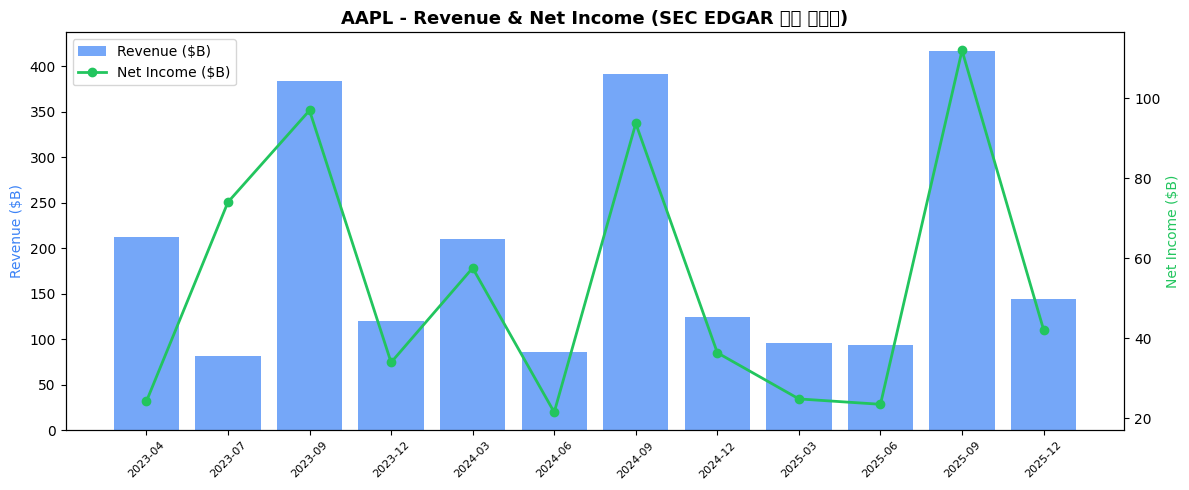

→ SEC 공식 데이터 기반 (yfinance보다 정확)


In [4]:
# 📊 매출 & 순이익 시각화 (SEC 공식 데이터)
fig, ax1 = plt.subplots(figsize=(12, 5))

rev = revenue_df.tail(12)
ni = net_income_df.tail(12)

quarters = [d.strftime('%Y-%m') for d in rev['end']]
ax1.bar(range(len(rev)), rev['val'].values / 1e9, color='#3b82f6', alpha=0.7, label='Revenue ($B)')
ax1.set_ylabel('Revenue ($B)', color='#3b82f6')
ax1.set_xticks(range(len(rev)))
ax1.set_xticklabels(quarters, rotation=45, fontsize=8)

ax2 = ax1.twinx()
# 순이익은 매출과 날짜가 다를 수 있으므로 매칭
ni_matched = ni[ni['end'].isin(rev['end'])]
if len(ni_matched) > 0:
    ni_quarters = [d.strftime('%Y-%m') for d in ni_matched['end']]
    ni_x = [quarters.index(q) for q in ni_quarters if q in quarters]
    ax2.plot(ni_x, ni_matched['val'].values[:len(ni_x)] / 1e9, 
             color='#22c55e', marker='o', linewidth=2, label='Net Income ($B)')
ax2.set_ylabel('Net Income ($B)', color='#22c55e')

ax1.set_title(f'AAPL - Revenue & Net Income (SEC EDGAR 공식 데이터)', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()
print("→ SEC 공식 데이터 기반 (yfinance보다 정확)")

### 9-2. EPS (주당순이익) 추이

In [5]:
# EPS (주당순이익) - 투자자가 가장 많이 보는 지표
eps_df = extract_quarterly(us_gaap, 'EarningsPerShareDiluted')

print("=== AAPL EPS (희석, 최근 12분기) ===")
eps_recent = eps_df.tail(12)
for _, row in eps_recent.iterrows():
    print(f"  {row['end'].strftime('%Y-%m-%d')} ({row['form']:4s}): ${row['val']:.2f}")

# EPS 시각화
fig, ax = plt.subplots(figsize=(10, 4))
quarters = [d.strftime('%Y-%m') for d in eps_recent['end']]
colors = ['#22c55e' if v > 0 else '#ef4444' for v in eps_recent['val']]
ax.bar(quarters, eps_recent['val'], color=colors, alpha=0.8)
ax.set_title('AAPL - EPS (Diluted) per Quarter', fontweight='bold')
ax.set_ylabel('EPS ($)')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: 'USD'

### 9-3. 재무상태표 (총자산, 부채, 자본)

=== AAPL 재무상태표 (최근 4분기) ===
  총자산       : $379.3B  (2025-12-27)
  총부채       : $291.1B  (2025-12-27)
  자기자본      : $88.2B  (2025-12-27)
  현금        : $45.3B  (2025-12-27)
  장기부채      : $88.5B  (2025-12-27)


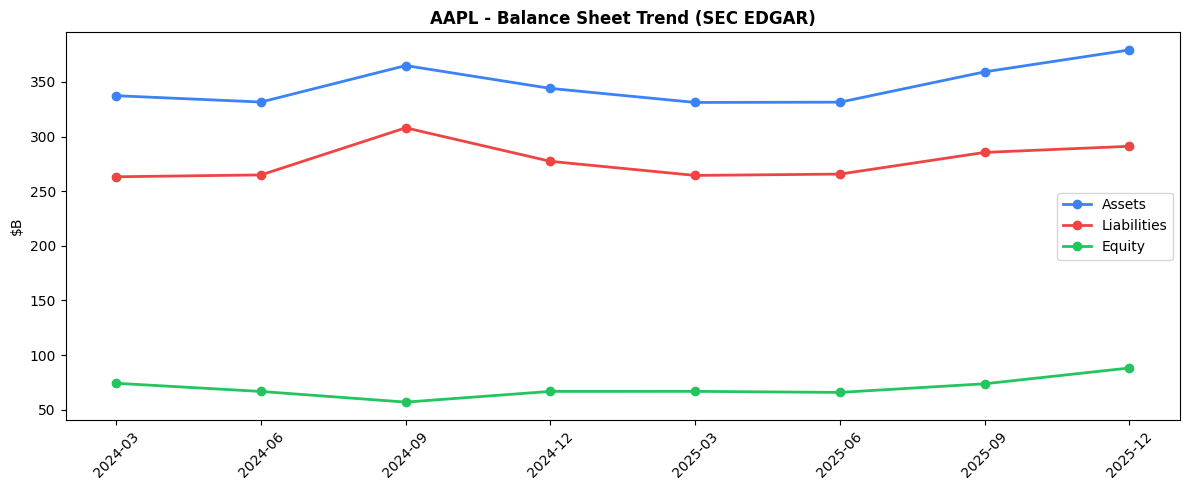

In [6]:
# 재무상태표 주요 항목
assets_df = extract_quarterly(us_gaap, 'Assets')
liabilities_df = extract_quarterly(us_gaap, 'Liabilities')
equity_df = extract_quarterly(us_gaap, 'StockholdersEquity')
cash_df = extract_quarterly(us_gaap, 'CashAndCashEquivalentsAtCarryingValue')
debt_df = extract_quarterly(us_gaap, 'LongTermDebt')

print("=== AAPL 재무상태표 (최근 4분기) ===")
for label, df in [("총자산", assets_df), ("총부채", liabilities_df), 
                   ("자기자본", equity_df), ("현금", cash_df), ("장기부채", debt_df)]:
    if len(df) > 0:
        latest = df.iloc[-1]
        print(f"  {label:10s}: ${latest['val']/1e9:.1f}B  ({latest['end'].strftime('%Y-%m-%d')})")

# 자산/부채/자본 추이 시각화
fig, ax = plt.subplots(figsize=(12, 5))

for label, df, color in [
    ("Assets", assets_df, '#3b82f6'), 
    ("Liabilities", liabilities_df, '#ef4444'),
    ("Equity", equity_df, '#22c55e'),
]:
    recent = df.tail(8)
    if len(recent) > 0:
        ax.plot([d.strftime('%Y-%m') for d in recent['end']], 
                recent['val'] / 1e9, marker='o', label=label, color=color, linewidth=2)

ax.set_title('AAPL - Balance Sheet Trend (SEC EDGAR)', fontweight='bold')
ax.set_ylabel('$B')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 9-4. 10-K / 10-Q 공시 목록 (사업보고서 / 분기보고서)

In [7]:
# SEC 공시 목록 가져오기 (10-K = 사업보고서, 10-Q = 분기보고서)
filings_url = f"https://data.sec.gov/submissions/CIK0000320193.json"
filings_res = requests.get(filings_url, headers=HEADERS)
filings = filings_res.json()

recent = filings['filings']['recent']
df_filings = pd.DataFrame({
    'date': recent['filingDate'],
    'form': recent['form'],
    'description': recent['primaryDocDescription'],
    'accession': recent['accessionNumber'],
})

# 10-K, 10-Q만 필터
annual_quarterly = df_filings[df_filings['form'].isin(['10-K', '10-Q', '8-K'])].head(20)

print(f"=== AAPL 최근 공시 (10-K/10-Q/8-K) ===")
print(f"{'날짜':12s} {'유형':6s} {'설명'}")
print("-" * 60)
for _, row in annual_quarterly.iterrows():
    form_label = {'10-K': '사업보고서', '10-Q': '분기보고서', '8-K': '수시공시'}.get(row['form'], row['form'])
    desc = (row['description'] or '')[:40]
    print(f"{row['date']:12s} {row['form']:6s} {form_label:10s} {desc}")

print(f"\n총 공시 수: {len(df_filings)}")
print(f"10-K (사업보고서): {len(df_filings[df_filings['form']=='10-K'])}건")
print(f"10-Q (분기보고서): {len(df_filings[df_filings['form']=='10-Q'])}건")
print(f"8-K (수시공시): {len(df_filings[df_filings['form']=='8-K'])}건")

=== AAPL 최근 공시 (10-K/10-Q/8-K) ===
날짜           유형     설명
------------------------------------------------------------
2026-02-24   8-K    수시공시       8-K
2026-01-30   10-Q   분기보고서      10-Q
2026-01-29   8-K    수시공시       8-K
2026-01-02   8-K    수시공시       8-K
2025-12-05   8-K    수시공시       8-K
2025-10-31   10-K   사업보고서      10-K
2025-10-30   8-K    수시공시       8-K
2025-08-01   10-Q   분기보고서      10-Q
2025-07-31   8-K    수시공시       8-K
2025-07-25   8-K    수시공시       8-K
2025-07-09   8-K    수시공시       8-K
2025-05-12   8-K    수시공시       8-K
2025-05-02   10-Q   분기보고서      10-Q
2025-05-01   8-K    수시공시       8-K
2025-02-25   8-K    수시공시       8-K
2025-01-31   10-Q   분기보고서      10-Q
2025-01-30   8-K    수시공시       8-K
2025-01-03   8-K    수시공시       FORM 8-K
2024-11-01   10-K   사업보고서      10-K
2024-10-31   8-K    수시공시       8-K

총 공시 수: 1000
10-K (사업보고서): 11건
10-Q (분기보고서): 33건
8-K (수시공시): 105건


### 9-5. 영업이익률 & 순이익률 추이 (수익성 분석)

=== AAPL 수익성 마진 추이 ===
         Gross Margin  Operating Margin  Net Margin
2024-03         46.2%             32.5%       27.4%
2024-06         46.3%             29.6%       25.0%
2024-09         46.2%             31.5%       24.0%
2024-12         46.9%             34.5%       29.2%
2025-03         47.1%             31.0%       26.0%
2025-06         46.5%             30.0%       24.9%
2025-09         46.9%             32.0%       26.9%
2025-12         48.2%             35.4%       29.3%


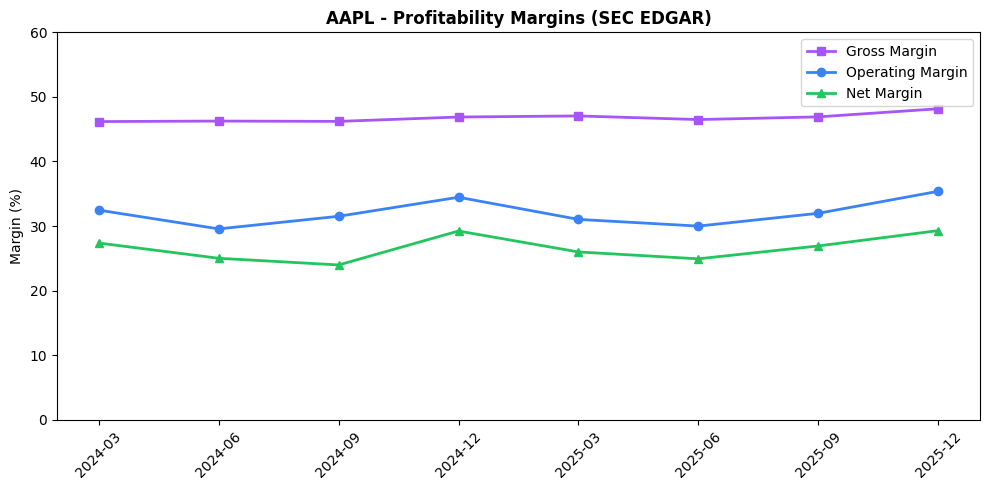

In [8]:
# 영업이익
op_income_df = extract_quarterly(us_gaap, 'OperatingIncomeLoss')
gross_df = extract_quarterly(us_gaap, 'GrossProfit')

# 매출 대비 마진 계산
rev_recent = revenue_df.set_index('end')['val']
op_recent = op_income_df.set_index('end')['val']
ni_recent = net_income_df.set_index('end')['val']
gross_recent = gross_df.set_index('end')['val']

# 공통 날짜만
common_dates = rev_recent.index.intersection(op_recent.index).intersection(ni_recent.index)
common_dates = sorted(common_dates)[-8:]  # 최근 8분기

margins = pd.DataFrame({
    'Revenue': [rev_recent[d] for d in common_dates],
    'Gross Margin': [gross_recent.get(d, 0) / rev_recent[d] * 100 if d in gross_recent.index else None for d in common_dates],
    'Operating Margin': [op_recent[d] / rev_recent[d] * 100 for d in common_dates],
    'Net Margin': [ni_recent[d] / rev_recent[d] * 100 for d in common_dates],
}, index=[d.strftime('%Y-%m') for d in common_dates])

print("=== AAPL 수익성 마진 추이 ===")
print(margins[['Gross Margin', 'Operating Margin', 'Net Margin']].to_string(float_format='%.1f%%'))

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
if margins['Gross Margin'].notna().any():
    ax.plot(margins.index, margins['Gross Margin'], marker='s', label='Gross Margin', color='#a855f7', linewidth=2)
ax.plot(margins.index, margins['Operating Margin'], marker='o', label='Operating Margin', color='#3b82f6', linewidth=2)
ax.plot(margins.index, margins['Net Margin'], marker='^', label='Net Margin', color='#22c55e', linewidth=2)
ax.set_title('AAPL - Profitability Margins (SEC EDGAR)', fontweight='bold')
ax.set_ylabel('Margin (%)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

### 9-6. 요약: SEC EDGAR vs yfinance 비교

| 항목 | SEC EDGAR | yfinance |
|------|-----------|---------|
| **데이터 출처** | 미국 정부 공식 | Yahoo Finance (비공식) |
| **정확도** | 공시 원본 그대로 | 가끔 누락/지연 |
| **API 키** | 불필요 (이메일만) | 불필요 |
| **비용** | 무료 | 무료 |
| **속도** | 느림 (1요청에 전체 이력) | 빠름 |
| **사용 편의** | JSON 파싱 필요 | `.info` 한 줄 |
| **공시 원문** | ✅ 10-K, 10-Q 원문 | ❌ |
| **실시간 주가** | ❌ | ✅ |

### 우리 프로젝트 권장 조합
```
실시간 주가/간편 지표 → yfinance (이미 사용 중)
정확한 재무제표/공시 → SEC EDGAR API (추가 예정)
국장 재무제표 → OpenDART API (향후)
```

### 9-7. 공시 원문 읽기 (10-K 사업보고서 내용 탐색)

SEC EDGAR에서 공시 HTML 원문을 가져와서 내용을 읽을 수 있음.

In [10]:
from bs4 import BeautifulSoup
import textwrap

# 최근 10-K (사업보고서) 찾기
ten_k = df_filings[df_filings['form'] == '10-K'].iloc[0]
accession = ten_k['accession'].replace('-', '')
filing_date = ten_k['date']

print(f"=== AAPL 최근 사업보고서 (10-K) ===")
print(f"제출일: {filing_date}")
print(f"Accession: {ten_k['accession']}")

# 공시 문서 목록 가져오기
index_url = f"https://www.sec.gov/Archives/edgar/data/320193/{accession}/index.json"
index_res = requests.get(index_url, headers=HEADERS)
index_data = index_res.json()

# 메인 HTML 문서 찾기
docs = index_data['directory']['item']
main_doc = None
for doc in docs:
    name = doc['name']
    if name.endswith('.htm') and '10-k' in name.lower():
        main_doc = name
        break
    elif name.endswith('.htm') and 'aapl' in name.lower():
        main_doc = name
        break

if not main_doc:
    # htm 파일 중 가장 큰 것 (보통 메인 문서)
    htm_docs = [d for d in docs if d['name'].endswith('.htm')]
    if htm_docs:
        main_doc = max(htm_docs, key=lambda d: int(d.get('size', 0)))['name']

print(f"메인 문서: {main_doc}")
print(f"\n문서 목록:")
for doc in docs[:10]:
    print(f"  {doc['name']:50s} {doc.get('size','?'):>10s} bytes")

=== AAPL 최근 사업보고서 (10-K) ===
제출일: 2025-10-31
Accession: 0000320193-25-000079
메인 문서: a10-kexhibit21109272025.htm

문서 목록:
  0000320193-25-000079-index-headers.html                       bytes
  0000320193-25-000079-index.html                               bytes
  0000320193-25-000079.txt                                      bytes
  0000320193-25-000079-xbrl.zip                          399390 bytes
  a10-kexhibit21109272025.htm                             11807 bytes
  a10-kexhibit23109272025.htm                              6251 bytes
  a10-kexhibit31109272025.htm                             10507 bytes
  a10-kexhibit31209272025.htm                             10543 bytes
  a10-kexhibit32109272025.htm                              8356 bytes
  a10-kexhibit4109272025.htm                             118590 bytes


In [11]:
# 10-K 원문 다운로드 & 파싱
doc_url = f"https://www.sec.gov/Archives/edgar/data/320193/{accession}/{main_doc}"
print(f"다운로드: {doc_url}\n")

doc_res = requests.get(doc_url, headers=HEADERS)
soup = BeautifulSoup(doc_res.text, 'html.parser')

# 텍스트 추출
full_text = soup.get_text(separator='\n', strip=True)
print(f"전체 문서 길이: {len(full_text):,}자")
print(f"전체 문서 줄 수: {len(full_text.splitlines()):,}줄")

# 목차(Table of Contents) 부분 찾기
lines = full_text.splitlines()
toc_start = None
for i, line in enumerate(lines):
    if 'table of contents' in line.lower() or 'index' in line.lower():
        toc_start = i
        break

if toc_start:
    print(f"\n=== 목차 (Table of Contents) ===")
    for line in lines[toc_start:toc_start+30]:
        if line.strip():
            print(f"  {line.strip()[:80]}")

다운로드: https://www.sec.gov/Archives/edgar/data/320193/000032019325000079/a10-kexhibit21109272025.htm

전체 문서 길이: 1,064자
전체 문서 줄 수: 50줄


In [12]:
# 특정 섹션 검색 (키워드로 원하는 부분 찾기)
def search_section(text, keyword, context_lines=10):
    """공시 원문에서 키워드 포함 섹션 찾기"""
    lines = text.splitlines()
    results = []
    for i, line in enumerate(lines):
        if keyword.lower() in line.lower():
            start = max(0, i - 1)
            end = min(len(lines), i + context_lines)
            section = '\n'.join(lines[start:end])
            results.append((i, section))
    return results

# 예시 1: "Risk Factors" (위험 요인) 검색
print("=" * 60)
print("🔍 검색: 'Risk Factors' (위험 요인)")
print("=" * 60)
risks = search_section(full_text, 'Risk Factors', context_lines=5)
if risks:
    print(f"총 {len(risks)}개 위치에서 발견")
    # 첫 번째 결과만 표시
    line_num, section = risks[0]
    print(f"\n[라인 {line_num}]")
    print(section[:500])
    print("...")

# 예시 2: "Revenue" (매출) 관련 내용
print("\n" + "=" * 60)
print("🔍 검색: 'Total net sales' (총 매출)")
print("=" * 60)
revenue_sections = search_section(full_text, 'Total net sales', context_lines=3)
for line_num, section in revenue_sections[:3]:
    print(f"\n[라인 {line_num}]")
    print(section[:300])

# 예시 3: "iPhone" 매출
print("\n" + "=" * 60)
print("🔍 검색: 'iPhone' 관련 내용")
print("=" * 60)
iphone = search_section(full_text, 'iPhone', context_lines=2)
print(f"'iPhone' 언급 횟수: {len(iphone)}회")
for line_num, section in iphone[:3]:
    print(f"\n[라인 {line_num}] {section[:200]}")

🔍 검색: 'Risk Factors' (위험 요인)

🔍 검색: 'Total net sales' (총 매출)

🔍 검색: 'iPhone' 관련 내용
'iPhone' 언급 횟수: 0회


In [13]:
# 💡 활용: 공시 원문을 AI에게 넘겨서 분석하기
# 전체 문서가 너무 길면(~10만자) 핵심 섹션만 추출

def extract_section(text, start_keyword, end_keyword, max_chars=5000):
    """두 키워드 사이의 섹션 추출"""
    lines = text.splitlines()
    start_idx = None
    end_idx = None
    
    for i, line in enumerate(lines):
        if start_keyword.lower() in line.lower() and start_idx is None:
            start_idx = i
        elif end_keyword.lower() in line.lower() and start_idx is not None:
            end_idx = i
            break
    
    if start_idx:
        section = '\n'.join(lines[start_idx:(end_idx or start_idx + 200)])
        return section[:max_chars]
    return "섹션을 찾지 못함"

# 사업 개요 (Business) 섹션 추출
business_section = extract_section(full_text, 'PART I', 'PART II', max_chars=3000)
print("=== PART I: 사업 개요 (처음 3000자) ===")
print(business_section[:3000])

print(f"\n\n→ 이 텍스트를 Gemini/ChatGPT/Claude에 넣으면:")
print("  '이 사업보고서를 분석해서 투자 포인트 3가지를 알려줘'")
print("  같은 프롬프트로 AI 분석이 가능합니다.")

=== PART I: 사업 개요 (처음 3000자) ===
섹션을 찾지 못함


→ 이 텍스트를 Gemini/ChatGPT/Claude에 넣으면:
  '이 사업보고서를 분석해서 투자 포인트 3가지를 알려줘'
  같은 프롬프트로 AI 분석이 가능합니다.


In [14]:
# 디버깅: 실제 문서 내용 확인
print(f"문서 길이: {len(full_text):,}자")
print(f"줄 수: {len(full_text.splitlines()):,}")
print()

# 처음 2000자 확인
print("=== 문서 처음 2000자 ===")
print(full_text[:2000])
print("\n...")

# 문서 중간 부분 확인
mid = len(full_text) // 2
print(f"\n=== 문서 중간 ({mid}자 위치) ===")
print(full_text[mid:mid+1000])

문서 길이: 1,064자
줄 수: 50

=== 문서 처음 2000자 ===
EX-21.1
3
a10-kexhibit21109272025.htm
EX-21.1
Document
Exhibit 21.1
Subsidiaries of
Apple Inc.*
Jurisdiction
of Incorporation
Apple Asia Limited
Hong Kong
Apple Asia LLC
Delaware, U.S.
Apple Canada Inc.
Canada
Apple Computer Trading (Shanghai) Co., Ltd.
China
Apple Distribution International Limited
Ireland
Apple India Private Limited
India
Apple Insurance Company, Inc.
Arizona, U.S.
Apple Japan, Inc.
Japan
Apple Korea Limited
South Korea
Apple Operations International Limited
Ireland
Apple Operations Limited
Ireland
Apple Operations Mexico, S.A. de C.V.
Mexico
Apple Pty Limited
Australia
Apple Services Pte. Ltd.
Singapore
Apple South Asia (Thailand) Limited
Thailand
Apple South Asia Pte. Ltd.
Singapore
Apple Vietnam Limited Liability Company
Vietnam
Braeburn Capital, Inc.
Nevada, U.S.
iTunes K.K.
Japan
*
Pursuant to Item 601(b)(21)(ii) of Regulation S-K, the names of other subsidiaries of Apple Inc. are omitted because, considered in the aggr

In [17]:
# 다른 방법: 10-K 문서를 직접 SEC full-text search로 가져오기

print("=== 공시 문서 전체 목록 ===")
for doc in docs:
    size = doc.get('size', '?')
    name = doc['name']
    if name.endswith(('.htm', '.html', '.txt')):
        print(f"  {name:60s} {str(size):>10s} bytes")

# 가장 큰 htm 파일이 메인 10-K 본문
htm_docs = [d for d in docs if d['name'].endswith(('.htm', '.html'))]

def safe_size(d):
    s = d.get('size', '0')
    try: return int(s)
    except: return 0

if htm_docs:
    largest = max(htm_docs, key=safe_size)
    print(f"\n가장 큰 문서 (메인 본문): {largest['name']} ({safe_size(largest):,} bytes)")
    
    # 이 문서 다운로드
    main_url = f"https://www.sec.gov/Archives/edgar/data/320193/{accession}/{largest['name']}"
    print(f"URL: {main_url}")
    
    main_res = requests.get(main_url, headers=HEADERS)
    main_soup = BeautifulSoup(main_res.text, 'html.parser')
    main_text = main_soup.get_text(separator='\n', strip=True)
    
    print(f"\n본문 길이: {len(main_text):,}자")
    print(f"\n=== 처음 3000자 ===")
    print(main_text[:3000])

=== 공시 문서 전체 목록 ===
  0000320193-25-000079-index-headers.html                                 bytes
  0000320193-25-000079-index.html                                         bytes
  0000320193-25-000079.txt                                                bytes
  a10-kexhibit21109272025.htm                                       11807 bytes
  a10-kexhibit23109272025.htm                                        6251 bytes
  a10-kexhibit31109272025.htm                                       10507 bytes
  a10-kexhibit31209272025.htm                                       10543 bytes
  a10-kexhibit32109272025.htm                                        8356 bytes
  a10-kexhibit4109272025.htm                                       118590 bytes
  aapl-20250927.htm                                               1520208 bytes
  R1.htm                                                            87855 bytes
  R10.htm                                                           29220 bytes
  R11.htm           

In [18]:
# 메인 본문에서 키워드 검색 재시도
if 'main_text' in dir() and len(main_text) > 0:
    print(f"본문 길이: {len(main_text):,}자\n")
    
    keywords = ['iPhone', 'Revenue', 'Risk Factor', 'PART I', 'Net sales', 
                'Products', 'Services', 'operating income', 'net income']
    
    for kw in keywords:
        count = main_text.lower().count(kw.lower())
        if count > 0:
            # 첫 번째 발견 위치의 앞뒤 텍스트
            idx = main_text.lower().index(kw.lower())
            snippet = main_text[max(0,idx-50):idx+200].replace('\n', ' ')
            print(f"✅ '{kw}' → {count}회 발견")
            print(f"   ...{snippet[:150]}...")
            print()
        else:
            print(f"❌ '{kw}' → 없음")
else:
    print("main_text가 비어있음 - 위 셀을 먼저 실행하세요")

본문 길이: 220,666자

✅ 'iPhone' → 27회 발견
   ...prehensiveIncomeMember 2025-09-27 0000320193 aapl:IPhoneMember 2024-09-29 2025-09-27 0000320193 aapl:IPhoneMember 2023-10-01 2024-09-28 0000320193 aap...

✅ 'Revenue' → 27회 발견
   ... the Company derives a significant portion of its revenues and/or has significant supply chain operations. Restrictive measures can increase the cost ...

✅ 'Risk Factor' → 5회 발견
   ... CONTENTS Page Part I Item 1. Business 1 Item 1A. Risk Factors 5 Item 1B. Unresolved Staff Comments 17 Item 1C. Cybersecurity 17 Item 2. Properties 17...

✅ 'PART I' → 21회 발견
   ...f shareholders are incorporated by reference into Part III of this Annual Report on Form 10-K where indicated. The Registrant’s definitive proxy state...

✅ 'Net sales' → 70회 발견
   ...rtain of its services. During 2025, the Company’s net sales through its direct and indirect distribution channels accounted for 40% and 60%, respectiv...

✅ 'Products' → 162회 발견
   ...riod that ends on the last Saturday of Se